# genetic leakage experiment on low sample size data

In [1]:
import sys
sys.path.append("/scratch/aszatkow/work/projects/PRIVET")

import time

from src.misc_utils import *
from src.data_utils import *
from src.nn_utils import *
from src.stats_utils import *
from src.privet import *

In [2]:
ngpu=1
device = torch.device("cuda:0" if (torch.cuda.is_available() and ngpu > 0) else "cpu")
print(device)

cpu


# Load data

In [3]:
train = load_data("/scratch/aszatkow/work/data/yri2.txt")
test = load_data("/scratch/aszatkow/work/data/yri3.txt")
synth = load_data("/scratch/aszatkow/work/data/yri1.txt")

In [4]:
N = train.shape[0]

train.shape, test.shape, synth.shape

((66, 33602), (66, 33602), (66, 33602))

# INITIALIZE LEAKAGE PARAMETERS

In [5]:
fake_range = np.linspace(0,0.4,5)
fake_range[0] = 0.001

copy_range = np.linspace(0,0.2,5)
copy_range[0] = 0.001

# INITIALIZE PRIVACY MAPS

In [6]:
heatmap_NPL=np.zeros((len(fake_range),len(copy_range)))

tp_grid_npl = np.zeros((len(fake_range), len(copy_range)))
fp_grid_npl = np.zeros((len(fake_range), len(copy_range)))
tn_grid_npl = np.zeros((len(fake_range), len(copy_range)))
fn_grid_npl = np.zeros((len(fake_range), len(copy_range)))

# COMPUTE 1-NN distances

In [7]:
#For the fit
#Train-Train
dist_NN_tr_tr,  dist_NN_tr_tr_idx = gpu_nearest_neighbors(torch.tensor(train), k=1,distance='hamming',chunk_size=128,device=device.type,verbose=False)
p_tr_tr_NN_dist, p_tr_tr_NN_idx = sorting(dist_NN_tr_tr, dist_NN_tr_tr_idx)
p_tr_tr_NN_dist, p_tr_tr_NN_idx = np.array(p_tr_tr_NN_dist), np.array(p_tr_tr_NN_idx)

In [8]:
#Needed to construct the pseudo-synthetic data
#Synth-Train
dist_NN_syn_tr_INIT, dist_NN_syn_tr_INIT_idx = gpu_nearest_neighbors(torch.tensor(synth), torch.tensor(train), k=1,distance='hamming',chunk_size=128,device=device.type,verbose=False)
p_syn_tr_NN_dist_INIT, p_syn_tr_NN_idx_INIT = sorting(dist_NN_syn_tr_INIT, dist_NN_syn_tr_INIT_idx)
p_syn_tr_NN_dist_INIT, p_syn_tr_NN_idx_INIT = np.array(p_syn_tr_NN_dist_INIT), np.array(p_syn_tr_NN_idx_INIT)
indices_s_tr_INIT = dist_NN_syn_tr_INIT_idx.squeeze(1)

# EVT FIT CDF on Train-Train

In [9]:
partition_start = 0.01
partition_end = 0.2

start = int(np.ceil(partition_start*N)) #int(0.01*N) # if N is small start = 0 --> problem with log
end = int(partition_end*N)

# Fit parameters (adjust start/end indices to avoid extremes)
intercept, alpha, std_err_intercept, std_err_alpha, sigma_Y_pred = fit_nearest_neighbor_cdf_weibull(p_tr_tr_NN_dist.reshape(-1,), start_idx=start, end_idx=end)

print(f"Estimated intercept = {intercept:.2f} ± {std_err_intercept:.2f}")
print(f"Estimated alpha = {alpha:.2f} ± {std_err_alpha:.2f}")

Estimated intercept = -461.14 ± 44.21
Estimated alpha = 51.85 ± 5.00


# RUNNER for PRIVET

### FILL PRIVACY MAPS

In [11]:
threshold=-3

In [12]:
start = time.time()
time_lst = []
for i,f_fake in enumerate(fake_range):
    print(f_fake)
    n = int(np.ceil(N*f_fake))
    flist=np.zeros((N,)).astype(bool) #this is the groundtruth
    flist[:n]=True
    for j,f_copy in enumerate(copy_range):

        fake = generate_fake_synth(train, synth, indices_s_tr_INIT, f_fake=f_fake, f_copy=f_copy)

        start_i_j = time.time()
        store_in_mat, p_syn_tr_NN_dist, p_syn_te_NN_dist = PRIVET(torch.tensor(train), torch.tensor(test), torch.tensor(fake), intercept, alpha, renormalization = None, distance='hamming', device=device.type, groundtruth = flist)
        end_i_j = time.time()
        time_lst.append(end_i_j-start_i_j)

        delta_pi = store_in_mat[:,0]
        flist_bis = store_in_mat[:,-1].astype(bool)

        NPL = delta_pi<=threshold

        tp_npl, fn_npl, fp_npl, tn_npl = get_predictions(NPL, flist_bis)

        heatmap_NPL[i,j] = NPL.sum()

        tp_grid_npl[i, j] = tp_npl
        fp_grid_npl[i, j] = fp_npl
        tn_grid_npl[i, j] = tn_npl
        fn_grid_npl[i, j] = fn_npl
        
        if j%10==0:
            print(rf"Δπ f_fake={f_fake}, f_copy={f_copy}, tp={tp_npl}, fp={fp_npl}, tn={tn_npl}, fn={fn_npl}")

        del fake

0.001
Δπ f_fake=0.001, f_copy=0.001, tp=0, fp=0, tn=65, fn=1
0.1
Δπ f_fake=0.1, f_copy=0.001, tp=0, fp=0, tn=59, fn=7
0.2
Δπ f_fake=0.2, f_copy=0.001, tp=0, fp=0, tn=52, fn=14
0.30000000000000004
Δπ f_fake=0.30000000000000004, f_copy=0.001, tp=0, fp=0, tn=46, fn=20
0.4
Δπ f_fake=0.4, f_copy=0.001, tp=0, fp=0, tn=39, fn=27


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

D_paths = {"PRIVET (NPL)" : heatmap_NPL,
 "PRIVET (NPL): TP" : tp_grid_npl,
 "PRIVET (NPL): FP" : fp_grid_npl,
 "PRIVET (NPL): TN" : tn_grid_npl,
 "PRIVET (NPL): FN" : fn_grid_npl,
}

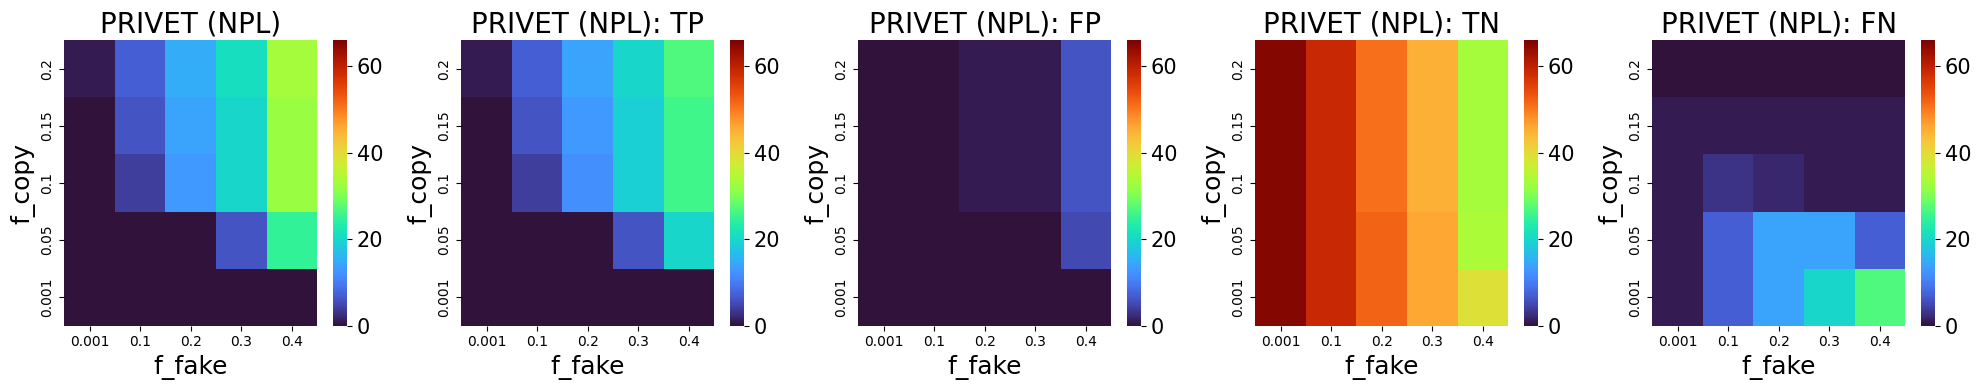

In [25]:

plt.rcParams.update({
    'axes.labelsize': 18,    # x and y labels
    'axes.titlesize': 20,    # subplot titles
    'xtick.labelsize': 10,   # x-axis ticks
    'ytick.labelsize': 10    # y-axis ticks
})

fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(20,4))
titles = list(D_paths)
data_grids = [D_paths[path] for path in D_paths]

vmin=0
vmax=66

for ax, data, title in zip(axes.flat, data_grids, titles):
    im = sns.heatmap(data.T, xticklabels=np.round(fake_range, 3), yticklabels=np.round(copy_range, 3), 
                         annot=False, cmap="turbo", ax=ax, cbar=True, vmin=vmin, vmax=vmax)
    ax.invert_yaxis()
    ax.set_xlabel("f_fake")
    ax.set_ylabel("f_copy")
    ax.set_title(title)

        # Access the colorbar and set its label size
    cbar = im.collections[0].colorbar
    if cbar:
        cbar.ax.tick_params(labelsize=15)  # Set colorbar tick label size

fig.tight_layout()